In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.models.scorecard import CreditScorecard

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("All imports successful")

All imports successful


In [2]:
lr_model = joblib.load('../models/logistic_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Load the WoE transformed data
X_train = pd.read_csv('../data/processed/X_train_woe.csv', index_col=0)
X_test  = pd.read_csv('../data/processed/X_test_woe.csv',  index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv',     index_col=0).squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv',      index_col=0).squeeze()

print(f"Model loaded    : {type(lr_model).__name__}")
print(f"Scaler loaded   : {type(scaler).__name__}")
print(f"X_train shape   : {X_train.shape}")
print(f"X_test shape    : {X_test.shape}")

Model loaded    : LogisticRegression
Scaler loaded   : StandardScaler
X_train shape   : (246008, 30)
X_test shape    : (61503, 30)


In [8]:
scorecard = CreditScorecard(
    model        = lr_model,
    scaler       = scaler,
    target_score = 600,
    target_odds  = 1.33,
    pdo          = 50,
    min_score    = 300,
    max_score    = 900
)

Scorecard initialized with:
  Target Score : 600
  Target Odds  : 1.33
  PDO          : 50
  Factor       : 72.1348
  Offset       : 579.4287
  Score Range  : 300 to 900


In [10]:
scored_df = scorecard.score_dataframe(X_test)
scored_df['Actual_Default'] = y_test.values

print(f"Scored {len(scored_df):,} applicants successfully")
print(f"\nScore Statistics:")
print(f"  Min Score    : {scored_df['Score'].min()}")
print(f"  Max Score    : {scored_df['Score'].max()}")
print(f"  Mean Score   : {scored_df['Score'].mean():.1f}")
print(f"  Median Score : {scored_df['Score'].median():.1f}")

print(f"\nRisk Category Distribution:")
print("-" * 40)
category_counts = scored_df['Risk_Category'].value_counts()
category_pct    = scored_df['Risk_Category'].value_counts(normalize=True) * 100
for cat in ['Excellent', 'Good', 'Fair', 'Poor', 'Very Poor']:
    if cat in category_counts:
        print(f"  {cat:<12} : {category_counts[cat]:>6,}  ({category_pct[cat]:.1f}%)")

Scored 61,503 applicants successfully

Score Statistics:
  Min Score    : 365
  Max Score    : 833
  Mean Score   : 603.7
  Median Score : 606.0

Risk Category Distribution:
----------------------------------------
  Excellent    :      8  (0.0%)
  Good         :  1,976  (3.2%)
  Fair         : 13,734  (22.3%)
  Poor         : 24,144  (39.3%)
  Very Poor    : 21,641  (35.2%)


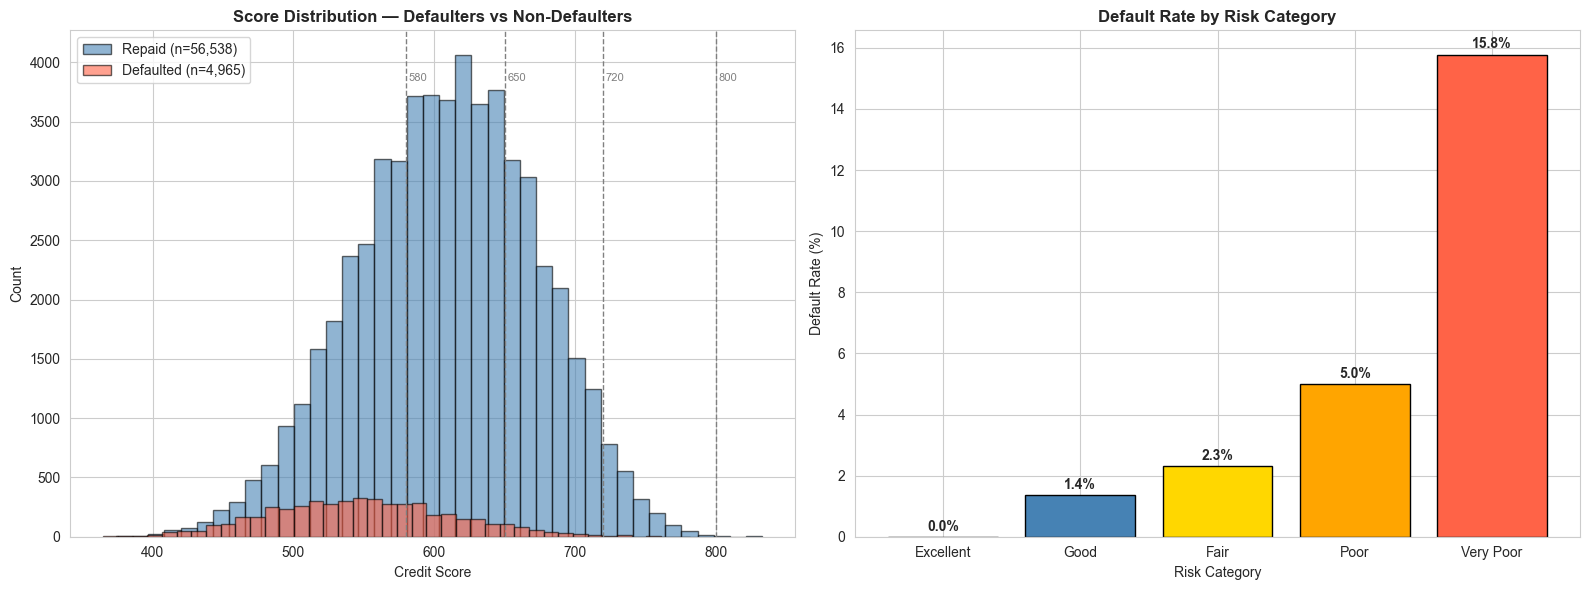

Plot saved to docs/scorecard_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1 — Score distribution for defaulters vs non-defaulters ---
defaulters     = scored_df[scored_df['Actual_Default'] == 1]['Score']
non_defaulters = scored_df[scored_df['Actual_Default'] == 0]['Score']

axes[0].hist(non_defaulters, bins=40, alpha=0.6, color='steelblue',
             edgecolor='black', label=f'Repaid (n={len(non_defaulters):,})')
axes[0].hist(defaulters,     bins=40, alpha=0.6, color='tomato',
             edgecolor='black', label=f'Defaulted (n={len(defaulters):,})')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution — Defaulters vs Non-Defaulters',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Add risk category boundary lines
for boundary, label in [(800, '800'), (720, '720'), (650, '650'), (580, '580')]:
    axes[0].axvline(x=boundary, color='gray', linestyle='--', linewidth=1)
    axes[0].text(boundary + 2, axes[0].get_ylim()[1] * 0.9,
                 label, fontsize=8, color='gray')

# --- Plot 2 — Default rate by risk category ---
default_rate_by_cat = scored_df.groupby('Risk_Category')['Actual_Default'].mean() * 100
ordered_cats = ['Excellent', 'Good', 'Fair', 'Poor', 'Very Poor']
default_rate_by_cat = default_rate_by_cat.reindex(
    [c for c in ordered_cats if c in default_rate_by_cat.index]
)

colors = ['darkgreen', 'steelblue', 'gold', 'orange', 'tomato'][:len(default_rate_by_cat)]
bars = axes[1].bar(default_rate_by_cat.index, default_rate_by_cat.values,
                   color=colors, edgecolor='black')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Risk Category', fontsize=12, fontweight='bold')
for bar, val in zip(bars, default_rate_by_cat.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/scorecard_distribution.png', bbox_inches='tight')
plt.show()

print("Plot saved to docs/scorecard_distribution.png")

In [12]:
repaid_idx   = scored_df[scored_df['Actual_Default'] == 0].index[0]
default_idx  = scored_df[scored_df['Actual_Default'] == 1].index[0]

for label, idx in [('REPAID APPLICANT', repaid_idx), ('DEFAULTED APPLICANT', default_idx)]:

    applicant    = X_test.loc[[idx]]
    score        = scorecard.calculate_score(applicant)[0]
    risk         = scorecard.get_risk_category(score)
    breakdown    = scorecard.get_score_breakdown(applicant, feature_names=X_test.columns.tolist())

    print("=" * 60)
    print(f"SCORE BREAKDOWN — {label}")
    print("=" * 60)
    print(f"Final Credit Score : {score}")
    print(f"Risk Category      : {risk}")
    print(f"\nPer Feature Breakdown:")
    print("-" * 60)
    print(f"{'Feature':<45} {'Points':>8}")
    print("-" * 60)

    for _, row in breakdown.iterrows():
        points = row['Points']
        marker = "+" if points >= 0 else "-"
        print(f"  {str(row['Feature']):<43} {points:>+8.2f}")

    print("-" * 60)
    print(f"  {'TOTAL SCORE':<43} {score:>8}")
    print()

SCORE BREAKDOWN — REPAID APPLICANT
Final Credit Score : 608
Risk Category      : Poor

Per Feature Breakdown:
------------------------------------------------------------
Feature                                         Points
------------------------------------------------------------
  Base Score (Intercept)                       +603.95
  NAME_EDUCATION_TYPE                           +19.04
  CREDIT_TO_ANNUITY_RATIO                       +17.88
  AMT_GOODS_PRICE                               +12.27
  EXT_SOURCE_2                                   +5.16
  YEARS_BEGINEXPLUATATION_AVG                    +4.29
  DAYS_ID_PUBLISH                                +4.03
  REGION_RATING_CLIENT_W_CITY                    +1.92
  FLOORSMAX_AVG                                  +1.89
  NAME_FAMILY_STATUS                             +1.53
  FLOORSMAX_MODE                                 +1.45
  NAME_INCOME_TYPE                               +1.31
  AGE_YEARS                                      +0.3

Scorecard saved to ../models/scorecard.pkl
Scored test set saved to data/processed/scored_test_set.csv


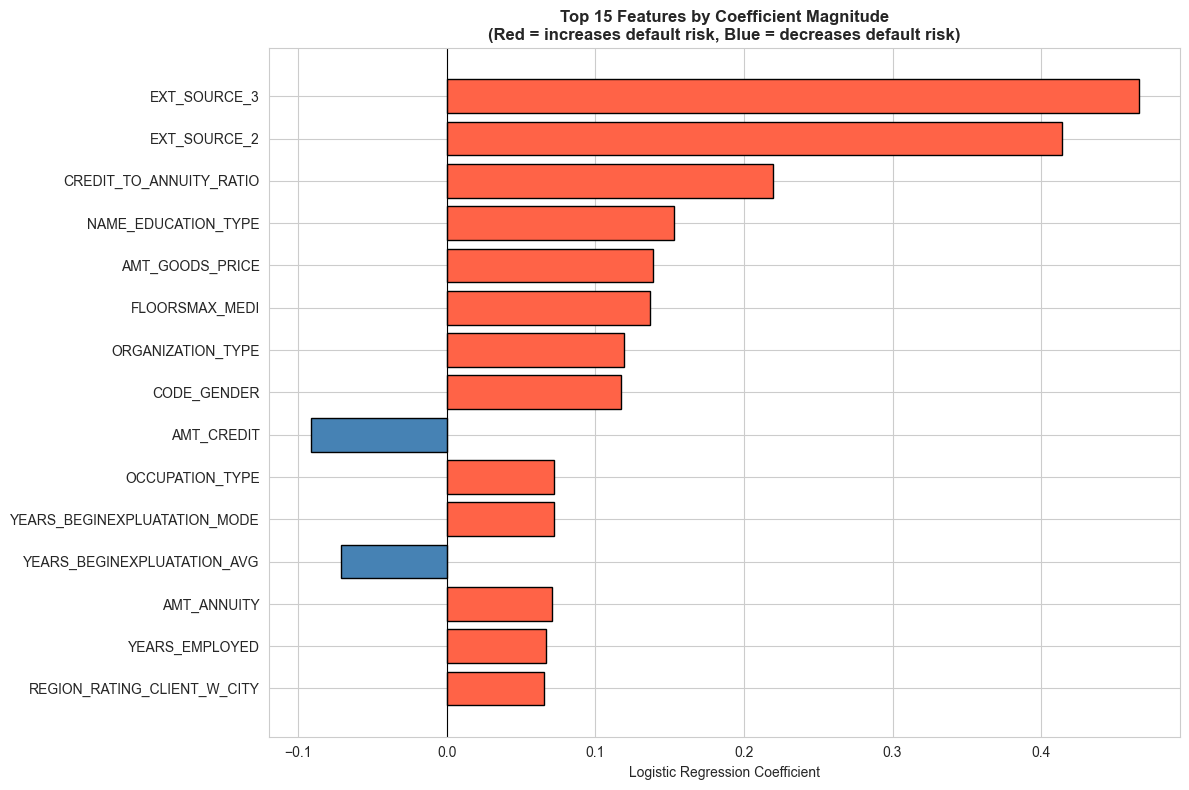

Scorecard table saved to docs/scorecard_table.png


In [13]:
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../docs', exist_ok=True)

# Save the scorecard object
scorecard.save('../models/scorecard.pkl')

# Save the full scored test set
scored_df.to_csv('../data/processed/scored_test_set.csv', index=True)
print("Scored test set saved to data/processed/scored_test_set.csv")

# Save the scorecard table image
# Show top features by absolute coefficient value
coef_df = pd.DataFrame({
    'Feature'     : X_test.columns.tolist(),
    'Coefficient' : lr_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).head(15)

plt.figure(figsize=(12, 8))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Logistic Regression Coefficient')
plt.title('Top 15 Features by Coefficient Magnitude\n(Red = increases default risk, Blue = decreases default risk)',
          fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/scorecard_table.png', bbox_inches='tight')
plt.show()

print("Scorecard table saved to docs/scorecard_table.png")